# Qwen Baseline and Supervised Fine-Tuning on RUKOPYS

Goal: evaluate a general-purpose Qwen vision-language checkpoint
and run an initial supervised fine-tuning experiment on gold annotations.

In [1]:
import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print("GPU:", gpu.name)
    print(f"Total VRAM: {gpu.total_memory / 1024**3:.1f} GiB")

    free_memory, _ = torch.cuda.mem_get_info()
    print(f"Free VRAM: {free_memory / 1024**3:.1f} GiB")
else:
    print("Enable a GPU runtime before loading the model.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Total VRAM: 14.6 GiB
Free VRAM: 14.5 GiB


## 1. Environment setup

We use Qwen3-VL-4B-Instruct as a general-purpose starting checkpoint.
The initial experiment uses 4-bit quantization to reduce GPU memory usage.

In [2]:
%pip install -q -U transformers accelerate peft bitsandbytes datasets pillow

In [3]:
import torch
import transformers
import accelerate
import peft
import bitsandbytes as bnb

from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("PEFT:", peft.__version__)
print("BitsAndBytes:", bnb.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Qwen3-VL imports: OK")

Transformers: 5.18.0
Accelerate: 1.15.0
PEFT: 0.21.2
BitsAndBytes: 0.50.2
CUDA available: True
Qwen3-VL imports: OK


## 2. Load the starting checkpoint

We load Qwen3-VL-4B-Instruct with 4-bit NF4 quantization.
FP16 is used for computation on the Tesla T4.
No fine-tuning has been performed yet.

In [4]:
from transformers import BitsAndBytesConfig
from huggingface_hub import model_info

MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"

# Record the exact checkpoint revision for reproducibility.
MODEL_REVISION = model_info(MODEL_ID).sha
print("Checkpoint:", MODEL_ID)
print("Revision:", MODEL_REVISION)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
)

torch.cuda.reset_peak_memory_stats()

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
    quantization_config=quantization_config,
    dtype=torch.float16,
    device_map={"": 0},
    attn_implementation="sdpa",
)
model.eval()

free_memory, total_memory = torch.cuda.mem_get_info()

print("\nModel loaded successfully.")
print(f"Allocated VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GiB")
print(f"Peak allocated VRAM: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB")
print(f"Free VRAM: {free_memory / 1024**3:.2f} GiB")

Checkpoint: Qwen/Qwen3-VL-4B-Instruct
Revision: ebb281ec70b05090aa6165b016eac8ec08e71b17


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]


Model loaded successfully.
Allocated VRAM: 2.71 GiB
Peak allocated VRAM: 2.73 GiB
Free VRAM: 11.68 GiB


## 3. Inspect a RUKOPYS training example

We stream a training page and extract a legible Ukrainian handwritten
region using its ground-truth bounding box.

This is a transcription smoke test, not an end-to-end evaluation.

README.md:   0%|          | 0.00/24.7k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/1331 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/9021 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1331 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/9021 [00:00<?, ?it/s]

Dataset revision: 78697007cfa5f77aae5d3b9fcedfac3169f84fb6
Source: dictation
Annotation source: annotator
Page size: (3468, 4624)
Bounding box: (395, 466, 2987, 866)
Crop size: (2592, 400)
Reference text: Спочатку був "брехунець". З нього почи-


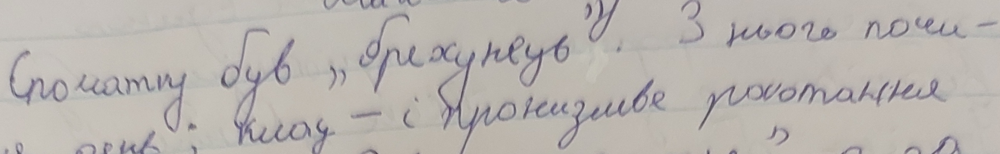

In [5]:
from datasets import load_dataset
from huggingface_hub import dataset_info
from IPython.display import display

DATASET_ID = "UkrainianCatholicUniversity/rukopys"
DATASET_REVISION = dataset_info(DATASET_ID).sha

train_stream = load_dataset(
    DATASET_ID,
    name="full",
    split="train",
    revision=DATASET_REVISION,
    streaming=True,
)

example = next(iter(train_stream))
page = example["image"].convert("RGB")

candidates = [
    region for region in example["regions"]
    if region["type"] == "handwritten"
    and region["language"] == "uk"
    and region["legibility"] == "legible"
    and region["text"].strip()
]

assert candidates, "No suitable handwritten region on this page."

# Prefer a full line over a short heading for the first check.
region = next(
    (r for r in candidates if len(r["text"]) >= 30),
    candidates[0],
)

bbox = tuple(region["bbox"])
crop = page.crop(bbox)
reference_text = region["text"]

print("Dataset revision:", DATASET_REVISION)
print("Source:", example["source"])
print("Annotation source:", example["annotation_source"])
print("Page size:", page.size)
print("Bounding box:", bbox)
print("Crop size:", crop.size)
print("Reference text:", reference_text)

display(crop)

## 4. Run initial transcription

The model receives only the image crop and a transcription instruction.
The reference text is used only for comparison after generation.

In [6]:
import time

TRANSCRIPTION_PROMPT = (
    "Transcribe the main handwritten Ukrainian text line in this image. "
    "Ignore fragments of neighboring lines at the image edges. "
    "Preserve the original spelling, punctuation, and trailing hyphens. "
    "Do not correct, translate, or complete the text. "
    "Return only the transcription."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": crop},
            {"type": "text", "text": TRANSCRIPTION_PROMPT},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False,
    )

torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time

generated_ids = outputs[:, inputs["input_ids"].shape[1]:]
prediction_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0].strip()

print("Reference:", reference_text)
print("Prediction:", prediction_text)
print(f"Inference time: {elapsed:.2f} seconds")
print(f"Peak allocated VRAM: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB")
print("Generated tokens:", generated_ids.shape[1])

Reference: Спочатку був "брехунець". З нього почи-
Prediction: Спочатку дуб » брехунець ». З іншого почи- - і протизнівців розсіяних
Inference time: 7.63 seconds
Peak allocated VRAM: 3.32 GiB
Generated tokens: 39


In [7]:
def levenshtein_distance(reference, prediction):
    previous = list(range(len(prediction) + 1))

    for i, ref_char in enumerate(reference, start=1):
        current = [i]

        for j, pred_char in enumerate(prediction, start=1):
            current.append(min(
                current[j - 1] + 1,       # insertion
                previous[j] + 1,          # deletion
                previous[j - 1] + (ref_char != pred_char),  # substitution
            ))

        previous = current

    return previous[-1]


edit_distance = levenshtein_distance(reference_text, prediction_text)
raw_cer = edit_distance / len(reference_text)

print("Reference:", repr(reference_text))
print("Prediction:", repr(prediction_text))
print("Character edits:", edit_distance)
print("Reference characters:", len(reference_text))
print(f"Raw CER: {raw_cer:.4f} ({raw_cer:.1%})")

Reference: 'Спочатку був "брехунець". З нього почи-'
Prediction: 'Спочатку дуб » брехунець ». З іншого почи- - і протизнівців розсіяних'
Character edits: 35
Reference characters: 39
Raw CER: 0.8974 (89.7%)


In [8]:
import unicodedata

print("Reference:", repr(reference_text))
print("Length:", len(reference_text))

for i, char in enumerate(reference_text):
    print(
        i,
        repr(char),
        f"U+{ord(char):04X}",
        unicodedata.name(char, "UNKNOWN"),
    )

edit_distance = levenshtein_distance(reference_text, prediction_text)
print("\nCharacter edits:", edit_distance)
print(f"Raw CER: {edit_distance / len(reference_text):.4f}")

Reference: 'Спочатку був "брехунець". З нього почи-'
Length: 39
0 'С' U+0421 CYRILLIC CAPITAL LETTER ES
1 'п' U+043F CYRILLIC SMALL LETTER PE
2 'о' U+043E CYRILLIC SMALL LETTER O
3 'ч' U+0447 CYRILLIC SMALL LETTER CHE
4 'а' U+0430 CYRILLIC SMALL LETTER A
5 'т' U+0442 CYRILLIC SMALL LETTER TE
6 'к' U+043A CYRILLIC SMALL LETTER KA
7 'у' U+0443 CYRILLIC SMALL LETTER U
8 ' ' U+0020 SPACE
9 'б' U+0431 CYRILLIC SMALL LETTER BE
10 'у' U+0443 CYRILLIC SMALL LETTER U
11 'в' U+0432 CYRILLIC SMALL LETTER VE
12 ' ' U+0020 SPACE
13 '"' U+0022 QUOTATION MARK
14 'б' U+0431 CYRILLIC SMALL LETTER BE
15 'р' U+0440 CYRILLIC SMALL LETTER ER
16 'е' U+0435 CYRILLIC SMALL LETTER IE
17 'х' U+0445 CYRILLIC SMALL LETTER HA
18 'у' U+0443 CYRILLIC SMALL LETTER U
19 'н' U+043D CYRILLIC SMALL LETTER EN
20 'е' U+0435 CYRILLIC SMALL LETTER IE
21 'ц' U+0446 CYRILLIC SMALL LETTER TSE
22 'ь' U+044C CYRILLIC SMALL LETTER SOFT SIGN
23 '"' U+0022 QUOTATION MARK
24 '.' U+002E FULL STOP
25 ' ' U+0020 SPACE
26 'З' U+0417 CYRI

In [9]:
# Select one suitable region per source, scanning at most 1,330 pages.
diagnostic_samples = {}
target_sources = {"dictation", "archive", "university", "school"}

for page_index, record in enumerate(train_stream.take(1330)):
    source = record["source"]

    if source in diagnostic_samples or source not in target_sources:
        continue

    suitable = [
        r for r in record["regions"]
        if r["type"] == "handwritten"
        and r["language"] == "uk"
        and r["legibility"] == "legible"
        and 30 <= len(r["text"]) <= 150
    ]

    if not suitable:
        continue

    selected_region = suitable[0]
    image = record["image"].convert("RGB")

    diagnostic_samples[source] = {
        "page_index": page_index,
        "bbox": selected_region["bbox"],
        "crop": image.crop(tuple(selected_region["bbox"])),
        "reference": selected_region["text"],
    }

    print(f"Selected {source}: page {page_index}")

    if set(diagnostic_samples) == target_sources:
        break

print("\nSources collected:", list(diagnostic_samples))

Selected dictation: page 0


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3578: DecompressionBombWarning: Image size (94080000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Selected archive: page 360
Selected university: page 486
Selected school: page 648

Sources collected: ['dictation', 'archive', 'university', 'school']



--- dictation ---


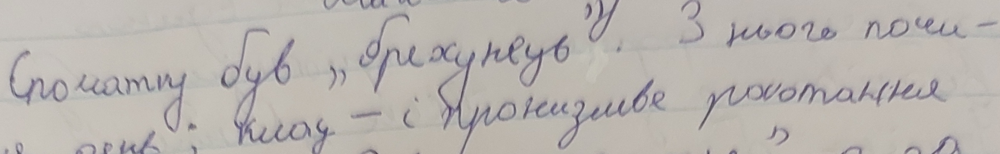

Reference: Спочатку був "брехунець". З нього почи-
Prediction: Спочатку дуб » брехунець ». З іншого почи- - і протизнівців розсіяних
Raw CER: 89.7%
Time: 4.28 s

--- archive ---


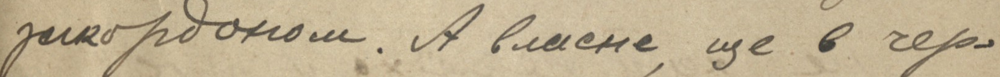

Reference: закордоном. А власне, ще в чер-
Prediction: декоративним. А відтак, ще в середній
Raw CER: 58.1%
Time: 2.17 s

--- university ---


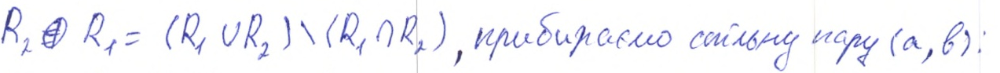

Reference: R_2 ⊕ R_1 = (R_1 ∪ R_2) \ (R_1 ∩ R_2), прибираємо спільну пару ( a.b):
Prediction: R₂⊕R₂=(R₁∪R₂)\(R₁∩R₂), прибираємо сімку пару (a,b):
Raw CER: 40.0%
Time: 2.91 s

--- school ---


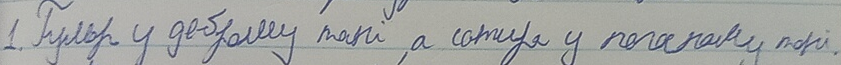

Reference: 1. Гумор у доброму тані, а сатира у поганому тоні.
Prediction: 1. Тутів у дотримку мані а соміла у поганому мані.
Raw CER: 30.0%
Time: 2.93 s


In [10]:
diagnostic_results = []

for source, sample in diagnostic_samples.items():
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": sample["crop"]},
            {"type": "text", "text": TRANSCRIPTION_PROMPT},
        ],
    }]

    batch = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.inference_mode():
        output = model.generate(
            **batch,
            max_new_tokens=128,
            do_sample=False,
        )

    torch.cuda.synchronize()
    seconds = time.perf_counter() - start

    new_tokens = output[:, batch["input_ids"].shape[1]:]
    prediction = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    reference = sample["reference"]
    edits = levenshtein_distance(reference, prediction)

    diagnostic_results.append({
        "source": source,
        "page_index": sample["page_index"],
        "reference": reference,
        "prediction": prediction,
        "edits": edits,
        "reference_length": len(reference),
        "raw_cer": edits / len(reference),
        "seconds": seconds,
        "hit_token_limit": new_tokens.shape[1] >= 128,
    })

    print(f"\n--- {source} ---")
    display(sample["crop"])
    print("Reference:", reference)
    print("Prediction:", prediction)
    print(f"Raw CER: {edits / len(reference):.1%}")
    print(f"Time: {seconds:.2f} s")

    if new_tokens.shape[1] >= 128:
        print("WARNING: generation reached the token limit.")

    del batch, output, new_tokens

In [11]:
import json
import importlib.metadata
from pathlib import Path
from google.colab import files

baseline_record = {
    "experiment": "qwen3_vl_4b_nf4_train_diagnostic",
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "split": "train",
    "evaluation": "four ground-truth crops; diagnostic only",
    "prompt": TRANSCRIPTION_PROMPT,
    "quantization": "4-bit NF4, double quantization, FP16 compute",
    "generation": {
        "max_new_tokens": 128,
        "do_sample": False,
    },
    "gpu": torch.cuda.get_device_name(0),
    "package_versions": {
        package: importlib.metadata.version(package)
        for package in [
            "torch", "transformers", "accelerate",
            "peft", "bitsandbytes", "datasets", "pillow",
        ]
    },
    "results": diagnostic_results,
}

result_path = Path("qwen_baseline_diagnostic.json")
result_path.write_text(
    json.dumps(baseline_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

files.download(str(result_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Prepare QLoRA adapters

The quantized base model remains frozen.
We train LoRA adapters on the language model's attention projections.

The initial four-crop experiment checks the training implementation;
it does not measure generalization.

In [12]:
import gc
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

# Release tensors left over from the first inference.
for variable_name in ("inputs", "outputs", "generated_ids"):
    globals().pop(variable_name, None)

gc.collect()
torch.cuda.empty_cache()

# Explicitly target language-model attention, excluding the vision encoder.
target_modules = [
    name
    for name, module in model.named_modules()
    if "language_model" in name
    and name.rsplit(".", 1)[-1]
    in {"q_proj", "k_proj", "v_proj", "o_proj"}
]

assert target_modules, "No language-model attention projections found."

print("Target modules:", len(target_modules))
print("Examples:", target_modules[:4])

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=target_modules,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.config.use_cache = False

model.print_trainable_parameters()

trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]

assert trainable_names, "No trainable parameters."
assert all("lora_" in name for name in trainable_names), (
    "Unexpected trainable parameters outside LoRA."
)

print("\nOnly LoRA parameters are trainable.")
print(f"Allocated VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GiB")

Target modules: 144
Examples: ['model.language_model.layers.0.self_attn.q_proj', 'model.language_model.layers.0.self_attn.k_proj', 'model.language_model.layers.0.self_attn.v_proj', 'model.language_model.layers.0.self_attn.o_proj']
trainable params: 5,898,240 || all params: 4,443,714,048 || trainable%: 0.1327

Only LoRA parameters are trainable.
Allocated VRAM: 3.47 GiB


## 6. Prepare and inspect a supervised batch

Each example contains an image, a user instruction, and a reference
transcription as the assistant response.

Only assistant response tokens, including the end-of-turn token,
contribute to the training loss.

In [13]:
def make_training_batch(sample):
    user_message = {
        "role": "user",
        "content": [
            {"type": "image", "image": sample["crop"]},
            {"type": "text", "text": TRANSCRIPTION_PROMPT},
        ],
    }

    prompt_batch = processor.apply_chat_template(
        [user_message],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )

    full_batch = processor.apply_chat_template(
        [
            user_message,
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": sample["reference"]}
                ],
            },
        ],
        tokenize=True,
        add_generation_prompt=False,
        return_dict=True,
        return_tensors="pt",
    )

    prompt_length = prompt_batch["input_ids"].shape[1]

    # Verify that the prompt is an exact prefix of the full conversation.
    assert torch.equal(
        prompt_batch["input_ids"],
        full_batch["input_ids"][:, :prompt_length],
    ), "Chat template prefix mismatch."

    labels = full_batch["input_ids"].clone()
    labels[:, :prompt_length] = -100
    labels[full_batch["attention_mask"] == 0] = -100

    assert (labels != -100).any(), "No supervised tokens."

    full_batch["labels"] = labels
    return full_batch


first_source = next(iter(diagnostic_samples))
training_batch = make_training_batch(diagnostic_samples[first_source])

supervised_ids = training_batch["labels"][0]
supervised_ids = supervised_ids[supervised_ids != -100]

print("Source:", first_source)
print("Input tokens:", training_batch["input_ids"].shape[1])
print("Supervised tokens:", supervised_ids.numel())
print(
    "Supervised content:",
    repr(processor.tokenizer.decode(
        supervised_ids,
        skip_special_tokens=False,
    )),
)
print("Batch fields:", list(training_batch))

Source: dictation
Input tokens: 1055
Supervised tokens: 22
Supervised content: 'Спочатку був "брехунець". З нього почи-<|im_end|>\n'
Batch fields: ['input_ids', 'attention_mask', 'mm_token_type_ids', 'pixel_values', 'image_grid_thw', 'labels']


In [14]:
model.train()
model.zero_grad(set_to_none=True)

training_batch = training_batch.to(model.device)
torch.cuda.reset_peak_memory_stats()

with torch.autocast(device_type="cuda", dtype=torch.float16):
    training_output = model(**training_batch)
    loss = training_output.loss

assert torch.isfinite(loss), "Non-finite loss."
print(f"Initial loss: {loss.item():.4f}")

loss.backward()

gradient_parameters = [
    name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad and parameter.grad is not None
]

assert gradient_parameters, "No adapter gradients."
assert all(
    torch.isfinite(parameter.grad).all().item()
    for parameter in model.parameters()
    if parameter.requires_grad and parameter.grad is not None
), "Non-finite gradients."

print("Adapter tensors with gradients:", len(gradient_parameters))
print(
    f"Peak allocated VRAM: "
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
)

# No optimizer step: adapter weights have not been updated.
model.zero_grad(set_to_none=True)
del training_batch, training_output, loss
gc.collect()
torch.cuda.empty_cache()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Initial loss: 1.2515
Adapter tensors with gradients: 288
Peak allocated VRAM: 6.70 GiB


## 7. Run a tiny QLoRA training experiment

We run 20 optimizer steps on four training crops, using batch size 1.
FP16 gradient scaling and gradient clipping are enabled.

This experiment checks whether the adapters can learn the training examples.
It is not a validation benchmark.

In [15]:
import random
from transformers import set_seed

set_seed(42)

# Cache only these four processed examples in CPU memory.
training_batches = {
    source: make_training_batch(sample)
    for source, sample in diagnostic_samples.items()
}

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=2e-4,
    weight_decay=0.0,
)

scaler = torch.amp.GradScaler("cuda")
trainable_parameters = [
    p for p in model.parameters() if p.requires_grad
]

training_history = []
rng = random.Random(42)
model.train()
torch.cuda.reset_peak_memory_stats()

step = 0

for epoch in range(5):
    sources = list(training_batches)
    rng.shuffle(sources)

    for source in sources:
        step += 1
        optimizer.zero_grad(set_to_none=True)

        # Create a GPU copy, keeping the cached batch on CPU.
        batch = {
            key: value.to(model.device)
            for key, value in training_batches[source].items()
        }

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            output = model(**batch, use_cache=False)
            loss = output.loss

        if not torch.isfinite(loss).item():
            raise RuntimeError(f"Non-finite loss at step {step}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        grad_norm = torch.nn.utils.clip_grad_norm_(
            trainable_parameters,
            max_norm=1.0,
            error_if_nonfinite=True,
        )

        scaler.step(optimizer)
        scaler.update()

        training_history.append({
            "step": step,
            "epoch": epoch + 1,
            "source": source,
            "loss": loss.item(),
            "grad_norm": grad_norm.item(),
        })

        print(
            f"Step {step:02d} | {source:10s} | "
            f"loss={loss.item():.4f}"
        )

        del batch, output, loss

    epoch_losses = [
        row["loss"]
        for row in training_history
        if row["epoch"] == epoch + 1
    ]
    print(
        f"Epoch {epoch + 1} mean loss: "
        f"{sum(epoch_losses) / len(epoch_losses):.4f}\n"
    )

optimizer.zero_grad(set_to_none=True)
model.eval()

print(
    f"Peak allocated VRAM: "
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
)

Step 01 | university | loss=0.8788
Step 02 | archive    | loss=0.4715
Step 03 | school     | loss=1.4084
Step 04 | dictation  | loss=1.2061
Epoch 1 mean loss: 0.9912

Step 05 | school     | loss=1.1823
Step 06 | university | loss=0.5047
Step 07 | dictation  | loss=0.6387
Step 08 | archive    | loss=0.2085
Epoch 2 mean loss: 0.6335

Step 09 | archive    | loss=0.1729
Step 10 | school     | loss=0.6866
Step 11 | university | loss=0.3417
Step 12 | dictation  | loss=0.2961
Epoch 3 mean loss: 0.3743

Step 13 | archive    | loss=0.0358
Step 14 | university | loss=0.2502
Step 15 | dictation  | loss=0.1099
Step 16 | school     | loss=0.2950
Epoch 4 mean loss: 0.1727

Step 17 | archive    | loss=0.0092
Step 18 | university | loss=0.1481
Step 19 | school     | loss=0.1414
Step 20 | dictation  | loss=0.0085
Epoch 5 mean loss: 0.0768

Peak allocated VRAM: 6.75 GiB


## 8. Compare transcription before and after tiny training

We evaluate the same four training crops with identical inference settings.
This measures fitting to the training examples, not generalization.

In [16]:
model.eval()
after_training_results = []

before_by_source = {
    row["source"]: row
    for row in diagnostic_results
}

for source, sample in diagnostic_samples.items():
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": sample["crop"]},
            {"type": "text", "text": TRANSCRIPTION_PROMPT},
        ],
    }]

    batch = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.inference_mode():
        output = model.generate(
            **batch,
            max_new_tokens=128,
            do_sample=False,
            use_cache=True,
        )

    torch.cuda.synchronize()
    seconds = time.perf_counter() - start

    new_tokens = output[:, batch["input_ids"].shape[1]:]
    prediction = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    reference = sample["reference"]
    edits = levenshtein_distance(reference, prediction)
    cer = edits / len(reference)

    after_training_results.append({
        "source": source,
        "page_index": sample["page_index"],
        "bbox": sample["bbox"],
        "reference": reference,
        "prediction": prediction,
        "edits": edits,
        "reference_length": len(reference),
        "raw_cer": cer,
        "seconds": seconds,
        "hit_token_limit": new_tokens.shape[1] >= 128,
    })

    print(f"\n--- {source} ---")
    print("Reference:", reference)
    print("Before:", before_by_source[source]["prediction"])
    print("After: ", prediction)
    print(
        f"Raw CER: {before_by_source[source]['raw_cer']:.1%}"
        f" → {cer:.1%}"
    )

    if new_tokens.shape[1] >= 128:
        print("WARNING: generation reached the token limit.")

    del batch, output, new_tokens


--- dictation ---
Reference: Спочатку був "брехунець". З нього почи-
Before: Спочатку дуб » брехунець ». З іншого почи- - і протизнівців розсіяних
After:  Спочатку був "брехунець". З нього почи-
Raw CER: 89.7% → 0.0%

--- archive ---
Reference: закордоном. А власне, ще в чер-
Before: декоративним. А відтак, ще в середній
After:  закордоном. А власне, ще в чер-
Raw CER: 58.1% → 0.0%

--- university ---
Reference: R_2 ⊕ R_1 = (R_1 ∪ R_2) \ (R_1 ∩ R_2), прибираємо спільну пару ( a.b):
Before: R₂⊕R₂=(R₁∪R₂)\(R₁∩R₂), прибираємо сімку пару (a,b):
After:  R_2 ⊕ R_1 = (R_1 ∪ R_2) \ (R_1 ∩ R_2), прибираємо спільну пару ( a.b):
Raw CER: 40.0% → 0.0%

--- school ---
Reference: 1. Гумор у доброму тані, а сатира у поганому тоні.
Before: 1. Тутів у дотримку мані а соміла у поганому мані.
After:  1. Гумор у доброму тані, а сатира у поганому тоні.
Raw CER: 30.0% → 0.0%


In [17]:
import shutil

output_dir = Path("qwen_tiny_qlora")
output_dir.mkdir(exist_ok=True)

model.save_pretrained(output_dir)
processor.save_pretrained(output_dir)

experiment_record = {
    "baseline": baseline_record,
    "training": {
        "purpose": "four-crop training smoke test",
        "seed": 42,
        "steps": len(training_history),
        "learning_rate": 2e-4,
        "batch_size": 1,
        "lora_r": 8,
        "lora_alpha": 16,
        "lora_dropout": 0.05,
        "target_modules": target_modules,
        "history": training_history,
    },
    "after_training": after_training_results,
}

(output_dir / "experiment.json").write_text(
    json.dumps(experiment_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "qwen_tiny_qlora",
    "zip",
    root_dir=str(output_dir),
)
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Inspect metadata before splitting

We inspect human-annotated training metadata without downloading all images.
The train/validation split must be defined before extracting crops.

Test data is reserved for final evaluation.

In [18]:
from huggingface_hub import hf_hub_download
from collections import Counter, defaultdict

metadata_path = hf_hub_download(
    repo_id=DATASET_ID,
    repo_type="dataset",
    filename="train/metadata.jsonl",
    revision=DATASET_REVISION,
)

with open(metadata_path, encoding="utf-8") as file:
    page_records = [
        json.loads(line)
        for line in file
        if line.strip()
    ]

page_ids = [record["file_name"] for record in page_records]
assert len(page_ids) == len(set(page_ids)), "Duplicate page filenames."

print("Pages:", len(page_records))
print("Fields:", sorted({
    key for record in page_records for key in record
}))
print("\nPages by source:")
print(dict(Counter(r["source"] for r in page_records)))

print("\nPages by annotation source:")
print(dict(Counter(
    r.get("annotation_source", "missing")
    for r in page_records
)))

print("\nGroup values by source:")
for source in sorted({r["source"] for r in page_records}):
    counts = Counter(
        str(r.get("group"))
        for r in page_records
        if r["source"] == source
    )
    print(source, dict(counts))

print("\nFirst page ID:", page_ids[0])

metadata.jsonl:   0%|          | 0.00/4.48M [00:00<?, ?B/s]

Pages: 1330
Fields: ['annotation_source', 'content_type', 'file_name', 'fund', 'grade', 'group', 'image_height', 'image_width', 'regions', 'source', 'source_detail', 'subject']

Pages by source:
{'dictation': 359, 'archive': 127, 'university': 162, 'school': 682}

Pages by annotation source:
{'annotator': 845, 'volunteer': 485}

Group values by source:
archive {'None': 127}
dictation {'None': 359}
school {'': 398, 'ukr_mova': 61, 'extra': 52, 'science': 40, 'math': 69, 'ukr_lit': 23, 'humanities': 19, 'other': 20}
university {'None': 162}

First page ID: images/09ba34df-2665-452c-9ef4-6998a5e7944c.jpg


In [19]:
def is_eligible_handwritten_region(region):
    text = region.get("text")
    bbox = region.get("bbox")

    return (
        region.get("type") == "handwritten"
        and region.get("language") == "uk"
        and region.get("legibility") == "legible"
        and isinstance(text, str)
        and bool(text.strip())
        and isinstance(bbox, list)
        and len(bbox) == 4
        and bbox[2] > bbox[0]
        and bbox[3] > bbox[1]
    )


eligible_counts = defaultdict(int)
pages_with_eligible_regions = Counter()

for record in page_records:
    regions = [
        region for region in record["regions"]
        if is_eligible_handwritten_region(region)
    ]

    eligible_counts[record["source"]] += len(regions)

    if regions:
        pages_with_eligible_regions[record["source"]] += 1

print("Eligible handwritten regions by source:")
print(dict(eligible_counts))

print("\nPages containing eligible regions:")
print(dict(pages_with_eligible_regions))

print("\nTotal eligible regions:", sum(eligible_counts.values()))

Eligible handwritten regions by source:
{'dictation': 8383, 'archive': 2454, 'university': 2538, 'school': 7995}

Pages containing eligible regions:
{'dictation': 359, 'archive': 125, 'university': 151, 'school': 653}

Total eligible regions: 21370


## 10. Create a reproducible page-level split

We reserve approximately 20% of human-annotated training pages
for validation, stratified by source.

All regions from a page belong to the same split.
Writer independence and text independence are not guaranteed.
The official test split remains untouched.

In [20]:
import hashlib
import math

SPLIT_SEED = 42
VALIDATION_FRACTION = 0.20

def page_split_key(page_id):
    value = f"{SPLIT_SEED}:{page_id}".encode("utf-8")
    return hashlib.sha256(value).hexdigest()


records_by_source = defaultdict(list)

for record in page_records:
    records_by_source[record["source"]].append(record)

train_page_records = []
validation_page_records = []

for source in sorted(records_by_source):
    records = sorted(
        records_by_source[source],
        key=lambda record: page_split_key(record["file_name"]),
    )

    validation_count = math.ceil(
        len(records) * VALIDATION_FRACTION
    )

    validation_page_records.extend(records[:validation_count])
    train_page_records.extend(records[validation_count:])

train_ids = {r["file_name"] for r in train_page_records}
validation_ids = {r["file_name"] for r in validation_page_records}

assert train_ids.isdisjoint(validation_ids)
assert train_ids | validation_ids == set(page_ids)

for split_name, records in [
    ("train", train_page_records),
    ("validation", validation_page_records),
]:
    region_count = sum(
        is_eligible_handwritten_region(region)
        for record in records
        for region in record["regions"]
    )

    print(f"\n{split_name}:")
    print("Pages:", len(records))
    print("Sources:", dict(Counter(r["source"] for r in records)))
    print("Eligible handwritten regions:", region_count)


train:
Pages: 1062
Sources: {'archive': 101, 'dictation': 287, 'school': 545, 'university': 129}
Eligible handwritten regions: 16845

validation:
Pages: 268
Sources: {'archive': 26, 'dictation': 72, 'school': 137, 'university': 33}
Eligible handwritten regions: 4525


In [21]:
split_manifest = {
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "seed": SPLIT_SEED,
    "validation_fraction": VALIDATION_FRACTION,
    "method": "source-stratified SHA256 ordering of page filenames",
    "limitations": [
        "Writer independence is not guaranteed.",
        "Canonical dictation text can overlap between train and validation.",
        "Four train crops were previously used for a separate smoke test.",
        "Gold SFT must start from a fresh adapter.",
    ],
    "train": sorted(train_ids),
    "validation": sorted(validation_ids),
}

split_path = Path("rukopys_gold_split_v1.json")
split_path.write_text(
    json.dumps(split_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

files.download(str(split_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Select a small gold pilot dataset

The pilot includes all four document sources.
We select up to 128 training crops and 32 validation crops
from disjoint pages, using deterministic selection.

Only legible Ukrainian handwritten regions with 10–150 characters
are included. This pilot excludes longer lines.

In [22]:
def select_pilot_regions(records, pages_per_source, regions_per_page):
    selected = []

    for source in sorted(target_sources):
        eligible_pages = []

        for record in records:
            if record["source"] != source:
                continue

            regions = [
                (index, region)
                for index, region in enumerate(record["regions"])
                if is_eligible_handwritten_region(region)
                and 10 <= len(region["text"]) <= 150
            ]

            if regions:
                eligible_pages.append((record, regions))

        eligible_pages.sort(
            key=lambda item: page_split_key(item[0]["file_name"])
        )

        for record, regions in eligible_pages[:pages_per_source]:
            regions.sort(
                key=lambda item: page_split_key(
                    f"{record['file_name']}:{item[0]}"
                )
            )

            for region_index, region in regions[:regions_per_page]:
                selected.append({
                    "page_id": record["file_name"],
                    "region_index": region_index,
                    "source": source,
                    "bbox": region["bbox"],
                    "reference": region["text"],
                })

    return selected


pilot_train_records = select_pilot_regions(
    train_page_records, pages_per_source=4, regions_per_page=8
)
pilot_validation_records = select_pilot_regions(
    validation_page_records, pages_per_source=2, regions_per_page=4
)

assert {
    r["page_id"] for r in pilot_train_records
}.isdisjoint({
    r["page_id"] for r in pilot_validation_records
})

for name, records in [
    ("train", pilot_train_records),
    ("validation", pilot_validation_records),
]:
    print(f"\n{name}:")
    print("Pages:", len({r["page_id"] for r in records}))
    print("Crops:", len(records))
    print("Crops by source:", dict(Counter(r["source"] for r in records)))


train:
Pages: 16
Crops: 124
Crops by source: {'archive': 32, 'dictation': 32, 'school': 29, 'university': 31}

validation:
Pages: 8
Crops: 31
Crops by source: {'archive': 8, 'dictation': 8, 'school': 8, 'university': 7}


In [23]:
from PIL import Image

def load_selected_crops(records):
    crops_by_page = defaultdict(list)
    for record in records:
        crops_by_page[record["page_id"]].append(record)

    samples = []

    for page_id, page_regions in crops_by_page.items():
        image_path = hf_hub_download(
            repo_id=DATASET_ID,
            repo_type="dataset",
            filename=f"train/{page_id}",
            revision=DATASET_REVISION,
        )

        with Image.open(image_path) as image:
            page = image.convert("RGB")

        for record in page_regions:
            x1, y1, x2, y2 = record["bbox"]
            assert 0 <= x1 < x2 <= page.width
            assert 0 <= y1 < y2 <= page.height

            samples.append({
                **record,
                "crop": page.crop((x1, y1, x2, y2)),
            })

        del page
        print("Loaded:", page_id)

    return samples


pilot_validation_samples = load_selected_crops(
    pilot_validation_records
)

print("\nValidation crops ready:", len(pilot_validation_samples))

train/images/8b77afde-ad27-4d1a-bd2e-dc5(…): reconstructing file:   0%|          |  0.00B /  548kB            

train/images/8b77afde-ad27-4d1a-bd2e-dc5(…): downloading bytes:           |  0.00B            

Loaded: images/8b77afde-ad27-4d1a-bd2e-dc5c5138edc4.jpg


train/images/29809bc1-15a1-4943-ba8b-17e(…): reconstructing file:   0%|          |  0.00B / 1.28MB            

train/images/29809bc1-15a1-4943-ba8b-17e(…): downloading bytes:           |  0.00B            

...

train/images/2fc24534-ee9b-4612-b743-347(…): downloading bytes:           |  0.00B            

Loaded: images/2fc24534-ee9b-4612-b743-34767c8c6d86.jpg


train/images/263c37b9-2186-40df-9e91-4b9(…): reconstructing file:   0%|          |  0.00B /  331kB            

train/images/263c37b9-2186-40df-9e91-4b9(…): downloading bytes:           |  0.00B            

Loaded: images/263c37b9-2186-40df-9e91-4b93d9cc36f3.jpg

Validation crops ready: 31


## 12. Evaluate the base model on pilot validation

The smoke-test adapter is disabled during baseline evaluation.
We report raw character error rate on ground-truth handwritten crops.

This is a transcription-only pilot metric, not the Kaggle composite score.

In [24]:
def evaluate_crops(samples):
    results = []
    model.eval()

    for index, sample in enumerate(samples, start=1):
        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": sample["crop"]},
                {"type": "text", "text": TRANSCRIPTION_PROMPT},
            ],
        }]

        batch = processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt",
        ).to(model.device)

        torch.cuda.synchronize()
        start = time.perf_counter()

        with torch.inference_mode():
            output = model.generate(
                **batch,
                max_new_tokens=128,
                do_sample=False,
                use_cache=True,
            )

        torch.cuda.synchronize()
        seconds = time.perf_counter() - start

        generated = output[:, batch["input_ids"].shape[1]:]
        prediction = processor.batch_decode(
            generated,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()

        reference = sample["reference"]
        edits = levenshtein_distance(reference, prediction)

        results.append({
            "page_id": sample["page_id"],
            "region_index": sample["region_index"],
            "source": sample["source"],
            "bbox": sample["bbox"],
            "reference": reference,
            "prediction": prediction,
            "edits": edits,
            "reference_length": len(reference),
            "raw_cer": edits / len(reference),
            "seconds": seconds,
            "hit_token_limit": generated.shape[1] >= 128,
        })

        print(
            f"{index:02d}/{len(samples)} | {sample['source']:10s} | "
            f"CER={edits / len(reference):.1%} | {seconds:.1f}s"
        )

        del batch, output, generated

    return results


with model.disable_adapter():
    pilot_baseline_results = evaluate_crops(
        pilot_validation_samples
    )

01/31 | archive    | CER=38.2% | 2.8s
02/31 | archive    | CER=61.5% | 2.6s
03/31 | archive    | CER=30.6% | 2.4s
04/31 | archive    | CER=43.3% | 1.8s
05/31 | archive    | CER=48.2% | 3.5s
06/31 | archive    | CER=58.0% | 2.1s
07/31 | archive    | CER=60.0% | 3.3s
08/31 | archive    | CER=57.8% | 3.3s
09/31 | dictation  | CER=28.6% | 2.9s
10/31 | dictation  | CER=48.6% | 2.8s
11/31 | dictation  | CER=41.7% | 1.1s
12/31 | dictation  | CER=17.9% | 1.9s
13/31 | dictation  | CER=52.6% | 1.2s
14/31 | dictation  | CER=32.7% | 3.0s
15/31 | dictation  | CER=48.1% | 4.2s
16/31 | dictation  | CER=26.4% | 3.2s
17/31 | school     | CER=20.7% | 1.8s
18/31 | school     | CER=30.8% | 1.0s
19/31 | school     | CER=4.3% | 1.7s
20/31 | school     | CER=0.0% | 1.6s
21/31 | school     | CER=7.1% | 1.2s
22/31 | school     | CER=12.0% | 1.9s
23/31 | school     | CER=23.5% | 2.2s
24/31 | school     | CER=20.0% | 0.8s
25/31 | university | CER=0.0% | 2.2s
26/31 | university | CER=18.4% | 2.2s
27/31 | universi

In [25]:
def summarize_cer(results):
    total_edits = sum(row["edits"] for row in results)
    total_characters = sum(row["reference_length"] for row in results)
    return total_edits / total_characters


print(f"\nOverall raw CER: {summarize_cer(pilot_baseline_results):.2%}")

for source in sorted(target_sources):
    rows = [
        row for row in pilot_baseline_results
        if row["source"] == source
    ]
    print(f"{source}: {summarize_cer(rows):.2%} ({len(rows)} crops)")

print(
    "Outputs reaching token limit:",
    sum(row["hit_token_limit"] for row in pilot_baseline_results),
)

pilot_record = {
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "split_manifest": split_manifest,
    "pilot_train": pilot_train_records,
    "pilot_validation": pilot_validation_records,
    "prompt": TRANSCRIPTION_PROMPT,
    "generation": {"max_new_tokens": 128, "do_sample": False},
    "metric": "raw corpus CER; no text normalization",
    "adapter_enabled": False,
    "baseline_results": pilot_baseline_results,
}

pilot_path = Path("qwen_gold_pilot_baseline.json")
pilot_path.write_text(
    json.dumps(pilot_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
files.download(str(pilot_path))


Overall raw CER: 32.72%
archive: 50.75% (8 crops)
dictation: 36.14% (8 crops)
school: 14.97% (8 crops)
university: 16.47% (7 crops)
Outputs reaching token limit: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Prepare a fresh adapter for the gold pilot

A new adapter is initialized independently of the four-crop smoke test.
Only gold_pilot parameters are trainable.

In [26]:
from copy import deepcopy

assert "gold_pilot" not in model.peft_config, (
    "gold_pilot already exists; do not initialize it twice."
)

# Release the smoke-test optimizer and its state.
for variable_name in ("optimizer", "scaler", "trainable_parameters"):
    globals().pop(variable_name, None)

gc.collect()
torch.cuda.empty_cache()

set_seed(42)

gold_lora_config = deepcopy(lora_config)
gold_lora_config.inference_mode = False

model.add_adapter("gold_pilot", gold_lora_config)
model.set_adapter("gold_pilot")

gold_trainable_names = [
    name for name, parameter in model.named_parameters()
    if parameter.requires_grad
]

assert gold_trainable_names
assert all(
    ".gold_pilot." in name and "lora_" in name
    for name in gold_trainable_names
), "Unexpected trainable parameters."

# Standard LoRA initialization has zero B matrices:
# the new adapter initially adds no change to the base model.
assert all(
    torch.count_nonzero(parameter).item() == 0
    for name, parameter in model.named_parameters()
    if "lora_B.gold_pilot." in name
)

print("Active adapter:", model.active_adapter)
model.print_trainable_parameters()
print("Fresh adapter initialization: OK")

Active adapter: gold_pilot
trainable params: 5,898,240 || all params: 4,449,612,288 || trainable%: 0.1326
Fresh adapter initialization: OK


In [27]:
pilot_train_samples = load_selected_crops(pilot_train_records)

assert {
    sample["page_id"] for sample in pilot_train_samples
}.isdisjoint({
    sample["page_id"] for sample in pilot_validation_samples
})

print("\nTraining crops ready:", len(pilot_train_samples))
print("Validation crops:", len(pilot_validation_samples))
print("Page overlap: 0")

train/images/f54e6efc-037f-4bd2-99cd-94a(…): reconstructing file:   0%|          |  0.00B /  465kB            

train/images/f54e6efc-037f-4bd2-99cd-94a(…): downloading bytes:           |  0.00B            

Loaded: images/f54e6efc-037f-4bd2-99cd-94aa9bf795ac.jpg


train/images/e3a38762-218e-4461-aeb5-a14(…): reconstructing file:   0%|          |  0.00B / 1.53MB            

train/images/e3a38762-218e-4461-aeb5-a14(…): downloading bytes:           |  0.00B            

...

train/images/20f54e7b-fb31-4e6a-b91a-579(…): downloading bytes:           |  0.00B            

Loaded: images/20f54e7b-fb31-4e6a-b91a-579da041a4bb.jpg


train/images/acb5f660-a0e4-45f6-8479-a36(…): reconstructing file:   0%|          |  0.00B /  628kB            

train/images/acb5f660-a0e4-45f6-8479-a36(…): downloading bytes:           |  0.00B            

Loaded: images/acb5f660-a0e4-45f6-8479-a368c2e15af6.jpg

Training crops ready: 124
Validation crops: 31
Page overlap: 0


## 14. Train the gold pilot for one epoch

Training uses 124 crops, microbatch size 1, and gradient accumulation 4.
The learning rate is fixed at 1e-4.

Validation crops are excluded from training.

In [28]:
assert model.active_adapter == "gold_pilot"
assert len(pilot_train_samples) == 124

set_seed(42)

GOLD_LEARNING_RATE = 1e-4
GRADIENT_ACCUMULATION = 4

gold_parameters = [
    p for p in model.parameters() if p.requires_grad
]

gold_optimizer = torch.optim.AdamW(
    gold_parameters,
    lr=GOLD_LEARNING_RATE,
    weight_decay=0.0,
)
gold_scaler = torch.amp.GradScaler("cuda")

order = list(range(len(pilot_train_samples)))
random.Random(42).shuffle(order)

gold_training_history = []
gold_optimizer.zero_grad(set_to_none=True)
model.train()
torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()
optimizer_step = 0

for position, sample_index in enumerate(order):
    sample = pilot_train_samples[sample_index]

    cpu_batch = make_training_batch(sample)
    batch = {
        key: value.to(model.device)
        for key, value in cpu_batch.items()
    }

    # Also handle a potentially shorter final accumulation group.
    group_start = (
        position // GRADIENT_ACCUMULATION
    ) * GRADIENT_ACCUMULATION
    group_size = min(
        GRADIENT_ACCUMULATION,
        len(order) - group_start,
    )

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        output = model(**batch, use_cache=False)
        raw_loss = output.loss
        scaled_loss = raw_loss / group_size

    if not torch.isfinite(raw_loss).item():
        raise RuntimeError(f"Non-finite loss at crop {position + 1}")

    gold_scaler.scale(scaled_loss).backward()

    gold_training_history.append({
        "crop_step": position + 1,
        "page_id": sample["page_id"],
        "region_index": sample["region_index"],
        "source": sample["source"],
        "loss": raw_loss.item(),
    })

    update_now = (
        (position + 1) % GRADIENT_ACCUMULATION == 0
        or position + 1 == len(order)
    )

    if update_now:
        gold_scaler.unscale_(gold_optimizer)
        torch.nn.utils.clip_grad_norm_(
            gold_parameters,
            max_norm=1.0,
            error_if_nonfinite=True,
        )
        gold_scaler.step(gold_optimizer)
        gold_scaler.update()
        gold_optimizer.zero_grad(set_to_none=True)

        optimizer_step += 1
        recent = gold_training_history[-group_size:]
        mean_loss = sum(r["loss"] for r in recent) / group_size

        print(
            f"Update {optimizer_step:02d} | "
            f"crops {position + 1}/{len(order)} | "
            f"mean loss={mean_loss:.4f}"
        )

    del cpu_batch, batch, output, raw_loss, scaled_loss

torch.cuda.synchronize()
gold_training_seconds = time.perf_counter() - start_time
gold_peak_vram = torch.cuda.max_memory_allocated() / 1024**3

model.eval()

print("\nEpoch completed.")
print("Optimizer updates:", optimizer_step)
print(
    "Mean training loss:",
    round(
        sum(r["loss"] for r in gold_training_history)
        / len(gold_training_history),
        4,
    ),
)
print(f"Training time: {gold_training_seconds / 60:.2f} minutes")
print(f"Peak allocated VRAM: {gold_peak_vram:.2f} GiB")

# Save the trained pilot adapter immediately.
model.save_pretrained(
    "qwen_gold_pilot_epoch1",
    selected_adapters=["gold_pilot"],
)
processor.save_pretrained("qwen_gold_pilot_epoch1")
print("Checkpoint saved: qwen_gold_pilot_epoch1")

Update 01 | crops 4/124 | mean loss=1.1474
Update 02 | crops 8/124 | mean loss=1.4209
Update 03 | crops 12/124 | mean loss=0.6157
Update 04 | crops 16/124 | mean loss=0.9990
Update 05 | crops 20/124 | mean loss=0.9738
Update 06 | crops 24/124 | mean loss=1.3758
Update 07 | crops 28/124 | mean loss=1.6090
Update 08 | crops 32/124 | mean loss=0.5801
Update 09 | crops 36/124 | mean loss=1.4794
Update 10 | crops 40/124 | mean loss=0.9455
Update 11 | crops 44/124 | mean loss=0.7789
Update 12 | crops 48/124 | mean loss=0.8504
Update 13 | crops 52/124 | mean loss=0.5334
Update 14 | crops 56/124 | mean loss=1.0636
Update 15 | crops 60/124 | mean loss=1.0295
Update 16 | crops 64/124 | mean loss=0.8122
Update 17 | crops 68/124 | mean loss=0.9032
Update 18 | crops 72/124 | mean loss=1.1535
Update 19 | crops 76/124 | mean loss=0.9097
Update 20 | crops 80/124 | mean loss=0.7830
Update 21 | crops 84/124 | mean loss=0.7169
Update 22 | crops 88/124 | mean loss=1.0962
Update 23 | crops 92/124 | mean lo

## 15. Evaluate the gold pilot after one epoch

We compare the trained adapter with the base model on the same
31 validation crops, using identical prompts and generation settings.

In [29]:
assert model.active_adapter == "gold_pilot"

# Keep the trained adapter enabled.
pilot_epoch1_results = evaluate_crops(pilot_validation_samples)

# Verify that both evaluations contain the same examples in the same order.
def result_ids(results):
    return [
        (row["page_id"], row["region_index"])
        for row in results
    ]

assert result_ids(pilot_baseline_results) == result_ids(
    pilot_epoch1_results
)

baseline_cer = summarize_cer(pilot_baseline_results)
epoch1_cer = summarize_cer(pilot_epoch1_results)

print("\n--- Validation comparison ---")
print(f"Base Qwen raw CER: {baseline_cer:.2%}")
print(f"Gold pilot raw CER: {epoch1_cer:.2%}")
print(
    f"CER reduction: {(baseline_cer - epoch1_cer) * 100:+.2f} "
    "percentage points"
)

for source in sorted(target_sources):
    before = [
        r for r in pilot_baseline_results if r["source"] == source
    ]
    after = [
        r for r in pilot_epoch1_results if r["source"] == source
    ]
    print(
        f"{source}: {summarize_cer(before):.2%}"
        f" → {summarize_cer(after):.2%}"
    )

print(
    "Outputs reaching token limit:",
    sum(r["hit_token_limit"] for r in pilot_epoch1_results),
)

01/31 | archive    | CER=29.4% | 2.6s
02/31 | archive    | CER=41.0% | 3.2s
03/31 | archive    | CER=33.3% | 3.4s
04/31 | archive    | CER=43.3% | 2.3s
05/31 | archive    | CER=53.6% | 3.6s
06/31 | archive    | CER=42.0% | 4.6s
07/31 | archive    | CER=93.3% | 4.8s
08/31 | archive    | CER=35.6% | 3.0s
09/31 | dictation  | CER=22.9% | 3.5s
10/31 | dictation  | CER=17.1% | 2.7s
11/31 | dictation  | CER=16.7% | 0.9s
12/31 | dictation  | CER=17.9% | 2.3s
13/31 | dictation  | CER=42.1% | 1.3s
14/31 | dictation  | CER=40.8% | 2.7s
15/31 | dictation  | CER=35.2% | 4.6s
16/31 | dictation  | CER=20.8% | 3.9s
17/31 | school     | CER=24.1% | 2.1s
18/31 | school     | CER=7.7% | 1.1s
19/31 | school     | CER=4.3% | 2.1s
20/31 | school     | CER=36.8% | 2.4s
21/31 | school     | CER=14.3% | 1.2s
22/31 | school     | CER=8.0% | 2.0s
23/31 | school     | CER=23.5% | 2.7s
24/31 | school     | CER=20.0% | 0.9s
25/31 | university | CER=0.0% | 2.9s
26/31 | university | CER=7.9% | 3.0s
27/31 | universit

In [30]:
gold_experiment_record = {
    **pilot_record,
    "experiment": "gold_pilot_epoch1",
    "training": {
        "adapter": "gold_pilot",
        "seed": 42,
        "epochs": 1,
        "microbatch_size": 1,
        "gradient_accumulation": GRADIENT_ACCUMULATION,
        "learning_rate": GOLD_LEARNING_RATE,
        "optimizer": "AdamW",
        "weight_decay": 0.0,
        "max_grad_norm": 1.0,
        "lora_r": 8,
        "lora_alpha": 16,
        "lora_dropout": 0.05,
        "target_modules": target_modules,
        "optimizer_updates": optimizer_step,
        "seconds": gold_training_seconds,
        "peak_allocated_vram_gib": gold_peak_vram,
        "history": gold_training_history,
    },
    "epoch1_results": pilot_epoch1_results,
    "baseline_raw_cer": baseline_cer,
    "epoch1_raw_cer": epoch1_cer,
}

checkpoint_dir = Path("qwen_gold_pilot_epoch1")
experiment_path = checkpoint_dir / "experiment.json"

experiment_path.write_text(
    json.dumps(gold_experiment_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "qwen_gold_pilot_epoch1",
    "zip",
    root_dir=str(checkpoint_dir),
)
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Largest improvements ===


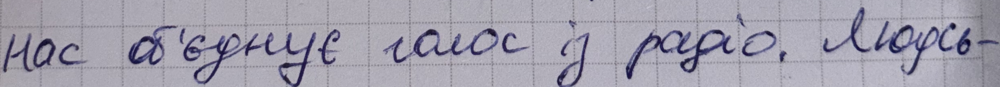

Source: dictation
Reference: нас об'єднує голос із радіо. Людсь-
Before: Нас оберігає таємна радість. Людсь-
After:  Нас обчує голос і радіо. Людсь-
CER: 48.6% → 17.1%



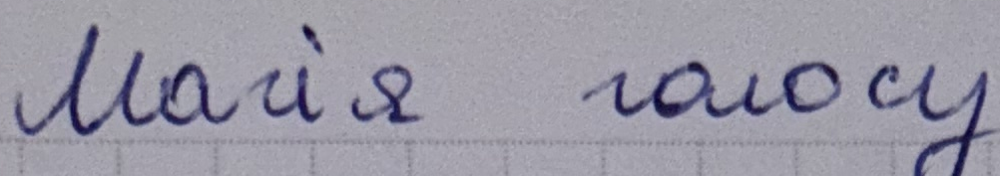

Source: dictation
Reference: Магія голосу
Before: Маців гаюсу
After:  Майя голосу
CER: 41.7% → 16.7%



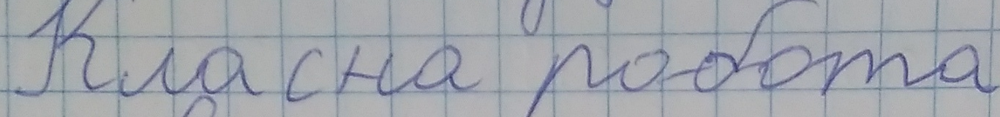

Source: school
Reference: Класна робота
Before: Кіласна подобота
After:  Класна побота
CER: 30.8% → 7.7%


=== Largest regressions ===


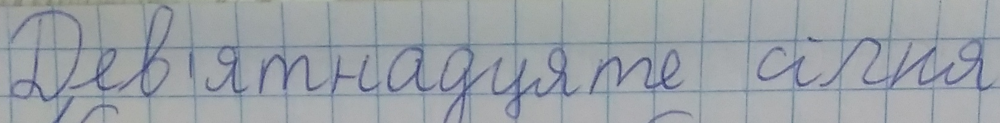

Source: school
Reference: Дев'ятнадцяте січня
Before: Дев'ятнадцяте січня
After:  Дебіантнадуяте сільня
CER: 0.0% → 36.8%



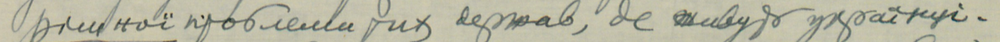

Source: archive
Reference: рішної проблеми тих справ, де живуть українці
Before: Дрібніші проблеми різьблення, де відсутні упірні.
After:  Орієнтовної пробільника руху відповідає, де він буде здійснюватися.
CER: 60.0% → 93.3%



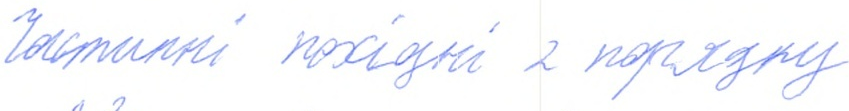

Source: university
Reference: Частинні похідні 2 порядку
Before: "Застави" посідні 2 поради
After:  "відтінки" посіють 2 пораджу
CER: 38.5% → 53.8%



In [31]:
comparison_rows = []

for before, after in zip(
    pilot_baseline_results,
    pilot_epoch1_results,
):
    comparison_rows.append({
        "page_id": after["page_id"],
        "region_index": after["region_index"],
        "source": after["source"],
        "reference": after["reference"],
        "before": before["prediction"],
        "after": after["prediction"],
        "before_cer": before["raw_cer"],
        "after_cer": after["raw_cer"],
        "cer_change": after["raw_cer"] - before["raw_cer"],
    })

sample_lookup = {
    (sample["page_id"], sample["region_index"]): sample
    for sample in pilot_validation_samples
}

ordered = sorted(comparison_rows, key=lambda row: row["cer_change"])

for title, rows in [
    ("Largest improvements", ordered[:3]),
    ("Largest regressions", list(reversed(ordered[-3:]))),
]:
    print(f"\n=== {title} ===")

    for row in rows:
        sample = sample_lookup[
            (row["page_id"], row["region_index"])
        ]

        display(sample["crop"])
        print("Source:", row["source"])
        print("Reference:", row["reference"])
        print("Before:", row["before"])
        print("After: ", row["after"])
        print(
            f"CER: {row['before_cer']:.1%}"
            f" → {row['after_cer']:.1%}\n"
        )

## 16. Continue the gold pilot for a second epoch

We retain the optimizer state and all training settings.
Only the number of training epochs changes.
Epoch 1 remains saved as a separate checkpoint.

In [32]:
assert model.active_adapter == "gold_pilot"

order_epoch2 = list(range(len(pilot_train_samples)))
random.Random(43).shuffle(order_epoch2)

gold_epoch2_history = []
gold_optimizer.zero_grad(set_to_none=True)
model.train()
torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()
epoch2_updates = 0

for position, sample_index in enumerate(order_epoch2):
    sample = pilot_train_samples[sample_index]
    cpu_batch = make_training_batch(sample)
    batch = {
        key: value.to(model.device)
        for key, value in cpu_batch.items()
    }

    group_start = (
        position // GRADIENT_ACCUMULATION
    ) * GRADIENT_ACCUMULATION
    group_size = min(
        GRADIENT_ACCUMULATION,
        len(order_epoch2) - group_start,
    )

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        output = model(**batch, use_cache=False)
        raw_loss = output.loss

    if not torch.isfinite(raw_loss).item():
        raise RuntimeError(f"Non-finite loss at crop {position + 1}")

    gold_scaler.scale(raw_loss / group_size).backward()

    gold_epoch2_history.append({
        "crop_step": position + 1,
        "page_id": sample["page_id"],
        "region_index": sample["region_index"],
        "source": sample["source"],
        "loss": raw_loss.item(),
    })

    if (
        (position + 1) % GRADIENT_ACCUMULATION == 0
        or position + 1 == len(order_epoch2)
    ):
        gold_scaler.unscale_(gold_optimizer)
        torch.nn.utils.clip_grad_norm_(
            gold_parameters,
            max_norm=1.0,
            error_if_nonfinite=True,
        )
        gold_scaler.step(gold_optimizer)
        gold_scaler.update()
        gold_optimizer.zero_grad(set_to_none=True)

        epoch2_updates += 1
        recent = gold_epoch2_history[-group_size:]
        print(
            f"Update {epoch2_updates:02d} | "
            f"mean loss="
            f"{sum(r['loss'] for r in recent) / group_size:.4f}"
        )

    del cpu_batch, batch, output, raw_loss

torch.cuda.synchronize()
gold_epoch2_seconds = time.perf_counter() - start_time
gold_epoch2_peak_vram = torch.cuda.max_memory_allocated() / 1024**3
model.eval()

model.save_pretrained(
    "qwen_gold_pilot_epoch2",
    selected_adapters=["gold_pilot"],
)
processor.save_pretrained("qwen_gold_pilot_epoch2")

print("\nEpoch 2 completed and saved.")
print(
    "Mean loss:",
    round(
        sum(r["loss"] for r in gold_epoch2_history)
        / len(gold_epoch2_history),
        4,
    ),
)
print(f"Time: {gold_epoch2_seconds / 60:.2f} minutes")
print(f"Peak VRAM: {gold_epoch2_peak_vram:.2f} GiB")

Update 01 | mean loss=0.7094
Update 02 | mean loss=0.9799
Update 03 | mean loss=0.3942
Update 04 | mean loss=0.6794
Update 05 | mean loss=0.8946
Update 06 | mean loss=0.6769
Update 07 | mean loss=0.9025
Update 08 | mean loss=0.4337
Update 09 | mean loss=0.6674
Update 10 | mean loss=0.9122
Update 11 | mean loss=1.5015
Update 12 | mean loss=1.0415
Update 13 | mean loss=0.6492
Update 14 | mean loss=0.4218
Update 15 | mean loss=0.4815
Update 16 | mean loss=0.7059
Update 17 | mean loss=0.4049
Update 18 | mean loss=0.7074
Update 19 | mean loss=0.5037
Update 20 | mean loss=0.6853
Update 21 | mean loss=0.5333
Update 22 | mean loss=0.4674
Update 23 | mean loss=0.7227
Update 24 | mean loss=0.5147
Update 25 | mean loss=0.8803
Update 26 | mean loss=0.6371
Update 27 | mean loss=0.4212
Update 28 | mean loss=0.6958
Update 29 | mean loss=0.4752
Update 30 | mean loss=0.6050
Update 31 | mean loss=0.5956

Epoch 2 completed and saved.
Mean loss: 0.6742
Time: 2.71 minutes
Peak VRAM: 7.32 GiB


In [33]:
pilot_epoch2_results = evaluate_crops(pilot_validation_samples)

assert result_ids(pilot_baseline_results) == result_ids(
    pilot_epoch2_results
)

epoch2_cer = summarize_cer(pilot_epoch2_results)

print("\n--- Overall raw CER ---")
print(f"Base:    {baseline_cer:.2%}")
print(f"Epoch 1: {epoch1_cer:.2%}")
print(f"Epoch 2: {epoch2_cer:.2%}")

for source in sorted(target_sources):
    scores = [
        summarize_cer([
            r for r in results if r["source"] == source
        ])
        for results in [
            pilot_baseline_results,
            pilot_epoch1_results,
            pilot_epoch2_results,
        ]
    ]
    print(
        f"{source}: "
        + " → ".join(f"{score:.2%}" for score in scores)
    )

print(
    "Outputs reaching token limit:",
    sum(r["hit_token_limit"] for r in pilot_epoch2_results),
)

01/31 | archive    | CER=5.9% | 2.5s
02/31 | archive    | CER=38.5% | 2.6s
03/31 | archive    | CER=27.8% | 2.4s
04/31 | archive    | CER=63.3% | 3.1s
05/31 | archive    | CER=57.1% | 4.0s
06/31 | archive    | CER=50.0% | 3.4s
07/31 | archive    | CER=55.6% | 4.0s
08/31 | archive    | CER=26.7% | 2.9s
09/31 | dictation  | CER=20.0% | 3.1s
10/31 | dictation  | CER=17.1% | 2.5s
11/31 | dictation  | CER=0.0% | 1.0s
12/31 | dictation  | CER=10.7% | 2.8s
13/31 | dictation  | CER=47.4% | 1.4s
14/31 | dictation  | CER=40.8% | 2.5s
15/31 | dictation  | CER=33.3% | 3.7s
16/31 | dictation  | CER=18.9% | 3.9s
17/31 | school     | CER=20.7% | 2.6s
18/31 | school     | CER=0.0% | 1.2s
19/31 | school     | CER=4.3% | 2.0s
20/31 | school     | CER=10.5% | 1.9s
21/31 | school     | CER=35.7% | 1.2s
22/31 | school     | CER=52.0% | 1.7s
23/31 | school     | CER=23.5% | 3.3s
24/31 | school     | CER=20.0% | 0.9s
25/31 | university | CER=0.0% | 2.9s
26/31 | university | CER=10.5% | 2.4s
27/31 | universit

## 17. Expand validation coverage

We evaluate up to four handwritten crops from ten validation pages
per source. This set may overlap with the pilot validation set.

We compare the base model and both saved checkpoints.
No additional training is performed.

In [34]:
expanded_validation_records = select_pilot_regions(
    validation_page_records,
    pages_per_source=10,
    regions_per_page=4,
)

assert {
    r["page_id"] for r in expanded_validation_records
}.isdisjoint(train_ids)

expanded_validation_samples = load_selected_crops(
    expanded_validation_records
)

print("\nExpanded validation:")
print("Pages:", len({
    r["page_id"] for r in expanded_validation_records
}))
print("Crops:", len(expanded_validation_samples))
print("Sources:", dict(Counter(
    r["source"] for r in expanded_validation_samples
)))

Loaded: images/8b77afde-ad27-4d1a-bd2e-dc5c5138edc4.jpg
Loaded: images/29809bc1-15a1-4943-ba8b-17ef7f9a4c91.jpg


train/images/18fbb3d3-0838-4d77-910c-fe9(…): reconstructing file:   0%|          |  0.00B /  641kB            

train/images/18fbb3d3-0838-4d77-910c-fe9(…): downloading bytes:           |  0.00B            

Loaded: images/18fbb3d3-0838-4d77-910c-fe90993d56c6.jpg


train/images/2104f71a-516c-4c3f-b74d-00f(…): reconstructing file:   0%|          |  0.00B / 1.57MB            

...

train/images/76df6cd2-dd5c-4ade-9945-c81(…): downloading bytes:           |  0.00B            

Loaded: images/76df6cd2-dd5c-4ade-9945-c81cc18880ba.jpg


train/images/12d93633-48dd-4138-863e-075(…): reconstructing file:   0%|          |  0.00B /  231kB            

train/images/12d93633-48dd-4138-863e-075(…): downloading bytes:           |  0.00B            

Loaded: images/12d93633-48dd-4138-863e-075b7bfc2de5.jpg

Expanded validation:
Pages: 40
Crops: 159
Sources: {'archive': 40, 'dictation': 40, 'school': 40, 'university': 39}


In [35]:
assert "gold_epoch1_eval" not in model.peft_config

model.load_adapter(
    "qwen_gold_pilot_epoch1/gold_pilot",
    adapter_name="gold_epoch1_eval",
    is_trainable=False,
)

print("Available adapters:", list(model.peft_config))

Available adapters: ['default', 'gold_pilot', 'gold_epoch1_eval']


In [36]:
expanded_results = {}

def save_expanded_results():
    record = {
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "dataset_id": DATASET_ID,
        "dataset_revision": DATASET_REVISION,
        "validation_records": expanded_validation_records,
        "prompt": TRANSCRIPTION_PROMPT,
        "generation": {
            "max_new_tokens": 128,
            "do_sample": False,
        },
        "metric": "raw corpus CER; no text normalization",
        "results": expanded_results,
    }
    Path("qwen_expanded_validation.json").write_text(
        json.dumps(record, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


print("\n=== Base Qwen ===")
with model.disable_adapter():
    expanded_results["base"] = evaluate_crops(
        expanded_validation_samples
    )
save_expanded_results()

print("\n=== Gold epoch 1 ===")
model.set_adapter("gold_epoch1_eval")
expanded_results["epoch1"] = evaluate_crops(
    expanded_validation_samples
)
save_expanded_results()

print("\n=== Gold epoch 2 ===")
model.set_adapter("gold_pilot")
expanded_results["epoch2"] = evaluate_crops(
    expanded_validation_samples
)
save_expanded_results()

assert (
    result_ids(expanded_results["base"])
    == result_ids(expanded_results["epoch1"])
    == result_ids(expanded_results["epoch2"])
)

print("\n=== Overall raw CER ===")
for name, results in expanded_results.items():
    print(f"{name}: {summarize_cer(results):.2%}")

print("\n=== Raw CER by source: base → epoch1 → epoch2 ===")
for source in sorted(target_sources):
    scores = [
        summarize_cer([
            r for r in expanded_results[name]
            if r["source"] == source
        ])
        for name in ("base", "epoch1", "epoch2")
    ]
    print(
        f"{source}: "
        + " → ".join(f"{score:.2%}" for score in scores)
    )

print("\n=== Outputs reaching token limit ===")
for name, results in expanded_results.items():
    print(name, sum(r["hit_token_limit"] for r in results))

files.download("qwen_expanded_validation.json")


=== Base Qwen ===
01/159 | archive    | CER=38.2% | 2.5s
02/159 | archive    | CER=61.5% | 2.6s
03/159 | archive    | CER=30.6% | 2.9s
04/159 | archive    | CER=43.3% | 1.8s
05/159 | archive    | CER=48.2% | 3.0s
06/159 | archive    | CER=58.0% | 2.1s
07/159 | archive    | CER=60.0% | 3.1s
08/159 | archive    | CER=57.8% | 3.9s
09/159 | archive    | CER=54.1% | 2.2s
10/159 | archive    | CER=74.2% | 2.1s
11/159 | archive    | CER=65.5% | 1.6s
12/159 | archive    | CER=92.6% | 2.3s
13/159 | archive    | CER=53.1% | 2.9s
14/159 | archive    | CER=77.8% | 3.9s
15/159 | archive    | CER=290.7% | 12.0s
16/159 | archive    | CER=54.7% | 3.3s
17/159 | archive    | CER=53.3% | 1.5s
18/159 | archive    | CER=70.3% | 2.1s
19/159 | archive    | CER=50.0% | 1.9s
20/159 | archive    | CER=70.6% | 2.8s
21/159 | archive    | CER=37.5% | 1.7s
22/159 | archive    | CER=32.1% | 1.7s
23/159 | archive    | CER=31.4% | 2.0s
24/159 | archive    | CER=29.0% | 2.1s
25/159 | archive    | CER=36.8% | 2.5s
26/1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
pilot_page_ids = {
    sample["page_id"]
    for sample in pilot_validation_samples
}

truncated_ids = {
    (row["page_id"], row["region_index"])
    for results in expanded_results.values()
    for row in results
    if row["hit_token_limit"]
}

print("=== Added validation pages only ===")
for name in ("base", "epoch1", "epoch2"):
    rows = [
        row for row in expanded_results[name]
        if row["page_id"] not in pilot_page_ids
    ]
    print(
        f"{name}: {summarize_cer(rows):.2%} | "
        f"{len(rows)} crops | "
        f"{len({r['page_id'] for r in rows})} pages"
    )

print("\n=== Shared subset without token-limit outputs ===")
for name in ("base", "epoch1", "epoch2"):
    rows = [
        row for row in expanded_results[name]
        if (row["page_id"], row["region_index"]) not in truncated_ids
    ]
    print(
        f"{name}: {summarize_cer(rows):.2%} | "
        f"{len(rows)} crops"
    )

print("\n=== Large-error outputs on the full set ===")
for name in ("base", "epoch1", "epoch2"):
    results = expanded_results[name]
    print(
        f"{name}: "
        f"{sum(r['raw_cer'] > 1 for r in results)} crops with CER > 100%; "
        f"{sum(r['hit_token_limit'] for r in results)} at token limit"
    )

=== Added validation pages only ===
base: 53.76% | 128 crops | 32 pages
epoch1: 46.00% | 128 crops | 32 pages
epoch2: 37.56% | 128 crops | 32 pages

=== Shared subset without token-limit outputs ===
base: 43.23% | 157 crops
epoch1: 39.51% | 157 crops
epoch2: 35.11% | 157 crops

=== Large-error outputs on the full set ===
base: 12 crops with CER > 100%; 2 at token limit
epoch1: 3 crops with CER > 100%; 1 at token limit
epoch2: 1 crops with CER > 100%; 0 at token limit


## 18. Select a larger gold training subset

We select up to 40 training pages per source and eight crops per page.
The validation set, region filters, and transcription prompt remain fixed.

This experiment starts from a fresh adapter.

In [38]:
gold_v1_train_records = select_pilot_regions(
    train_page_records,
    pages_per_source=40,
    regions_per_page=8,
)

gold_v1_page_ids = {
    record["page_id"] for record in gold_v1_train_records
}

assert gold_v1_page_ids <= train_ids
assert gold_v1_page_ids.isdisjoint(validation_ids)

print("Training pages:", len(gold_v1_page_ids))
print("Training crops:", len(gold_v1_train_records))
print(
    "Crops by source:",
    dict(Counter(r["source"] for r in gold_v1_train_records)),
)

gold_v1_manifest = {
    "experiment": "gold_v1",
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "split_seed": SPLIT_SEED,
    "selection": {
        "pages_per_source": 40,
        "max_regions_per_page": 8,
        "min_characters": 10,
        "max_characters": 150,
    },
    "train": gold_v1_train_records,
    "validation": expanded_validation_records,
}

manifest_path = Path("rukopys_gold_v1_manifest.json")
manifest_path.write_text(
    json.dumps(gold_v1_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
files.download(str(manifest_path))

Training pages: 160
Training crops: 1134
Crops by source: {'archive': 292, 'dictation': 320, 'school': 256, 'university': 266}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 19. Prepare persistent storage and a fresh gold adapter

Checkpoints are stored in Google Drive.
Training will save adapter weights, optimizer state, gradient scaler state,
progress, and random number generator states.

In [40]:
from google.colab import drive

drive.mount("/content/drive")

RUN_DIR = Path(
    "/content/drive/MyDrive/mavka-rukopys/runs/gold_v1"
)
RUN_DIR.mkdir(parents=True, exist_ok=True)

(RUN_DIR / "manifest.json").write_text(
    json.dumps(gold_v1_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Run directory:", RUN_DIR)

Mounted at /content/drive
Run directory: /content/drive/MyDrive/mavka-rukopys/runs/gold_v1


In [41]:
assert "gold_v1" not in model.peft_config, (
    "gold_v1 already exists; do not initialize it twice."
)

# Release the pilot optimizer state.
for variable_name in (
    "gold_optimizer", "gold_scaler", "gold_parameters",
):
    globals().pop(variable_name, None)

gc.collect()
torch.cuda.empty_cache()

set_seed(42)

gold_v1_config = deepcopy(lora_config)
gold_v1_config.inference_mode = False

model.add_adapter("gold_v1", gold_v1_config)
model.set_adapter("gold_v1")

gold_v1_parameters = [
    parameter
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
]

assert all(
    ".gold_v1." in name
    for name, parameter in model.named_parameters()
    if parameter.requires_grad
)

assert all(
    torch.count_nonzero(parameter).item() == 0
    for name, parameter in model.named_parameters()
    if "lora_B.gold_v1." in name
)

print("Active adapter:", model.active_adapter)
model.print_trainable_parameters()
print("Fresh initialization: OK")

Active adapter: gold_v1
trainable params: 5,898,240 || all params: 4,461,408,768 || trainable%: 0.1322
Fresh initialization: OK


In [42]:
gold_v1_train_samples = load_selected_crops(gold_v1_train_records)

print("\nTraining crops ready:", len(gold_v1_train_samples))
assert len(gold_v1_train_samples) == 1134

Loaded: images/f54e6efc-037f-4bd2-99cd-94aa9bf795ac.jpg
Loaded: images/e3a38762-218e-4461-aeb5-a14a9e1ba047.jpg
Loaded: images/503dc12c-0cf7-4b09-a17f-615c55ca2106.jpg
Loaded: images/4ebc8b4b-e5cd-4ed7-b8ca-361ba7305936.jpg


train/images/2bb89da4-f8e8-4726-afe1-a65(…): reconstructing file:   0%|          |  0.00B /  969kB            

train/images/2bb89da4-f8e8-4726-afe1-a65(…): downloading bytes:           |  0.00B            

Loaded: images/2bb89da4-f8e8-4726-afe1-a654976af35a.jpg


train/images/169d0e14-29a2-4a8e-948d-f01(…): reconstructing file:   0%|          |  0.00B / 1.54MB            

...

train/images/3abd7b4f-1e2a-45df-ab9a-37e(…): downloading bytes:           |  0.00B            

Loaded: images/3abd7b4f-1e2a-45df-ab9a-37ee85d074ab.jpg


train/images/92955b9d-e227-4b8e-82bd-c63(…): reconstructing file:   0%|          |  0.00B /  261kB            

train/images/92955b9d-e227-4b8e-82bd-c63(…): downloading bytes:           |  0.00B            

Loaded: images/92955b9d-e227-4b8e-82bd-c630af1ea8e5.jpg

Training crops ready: 1134


## 20. Train gold_v1 with resumable checkpoints

We train a fresh adapter for one epoch on 1,134 gold crops.
Microbatch size is 1; gradient accumulation is 4; learning rate is 1e-4.

Checkpoints are saved every 50 optimizer updates and at epoch completion.
Validation data is excluded from training.

In [43]:
assert model.active_adapter == "gold_v1"
assert len(gold_v1_train_samples) == 1134
assert "gold_v1_optimizer" not in globals(), (
    "Optimizer already initialized. Do not reset it during training."
)

set_seed(42)

gold_v1_optimizer = torch.optim.AdamW(
    gold_v1_parameters,
    lr=1e-4,
    weight_decay=0.0,
)
gold_v1_scaler = torch.amp.GradScaler("cuda")

gold_v1_order = list(range(len(gold_v1_train_samples)))
random.Random(42).shuffle(gold_v1_order)

gold_v1_history = []
gold_v1_next_position = 0
gold_v1_updates = 0

run_config = {
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "dataset_revision": DATASET_REVISION,
    "adapter": "gold_v1",
    "seed": 42,
    "epochs": 1,
    "learning_rate": 1e-4,
    "microbatch_size": 1,
    "gradient_accumulation": 4,
    "weight_decay": 0.0,
    "max_grad_norm": 1.0,
    "prompt": TRANSCRIPTION_PROMPT,
    "packages": baseline_record["package_versions"],
}

(RUN_DIR / "config.json").write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

def save_gold_v1_checkpoint():
    checkpoint = RUN_DIR / f"step_{gold_v1_updates:04d}"
    checkpoint.mkdir(exist_ok=True)

    model.save_pretrained(
        checkpoint,
        selected_adapters=["gold_v1"],
    )
    processor.save_pretrained(checkpoint)

    state = {
        "optimizer": gold_v1_optimizer.state_dict(),
        "scaler": gold_v1_scaler.state_dict(),
        "order": gold_v1_order,
        "next_position": gold_v1_next_position,
        "updates": gold_v1_updates,
        "history": gold_v1_history,
        "python_rng": random.getstate(),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all(),
        "config": run_config,
    }

    # Write the completion marker only after all checkpoint files are saved.
    temporary_path = checkpoint / "training_state.tmp"
    torch.save(state, temporary_path)
    temporary_path.replace(checkpoint / "training_state.pt")

    (checkpoint / "COMPLETE").write_text("OK", encoding="utf-8")
    (RUN_DIR / "latest_checkpoint.txt").write_text(
        checkpoint.name, encoding="utf-8"
    )
    print("Checkpoint saved:", checkpoint.name)


save_gold_v1_checkpoint()

Checkpoint saved: step_0000


In [46]:
assert model.active_adapter == "gold_v1"
assert len(gold_v1_history) == gold_v1_next_position

model.train()
gold_v1_optimizer.zero_grad(set_to_none=True)
torch.cuda.reset_peak_memory_stats()

session_start = time.perf_counter()
accumulation = 4

while gold_v1_next_position < len(gold_v1_order):
    group_start = gold_v1_next_position
    group_indices = gold_v1_order[
        group_start:group_start + accumulation
    ]

    for attempt in range(1, 5):
        gold_v1_optimizer.zero_grad(set_to_none=True)
        group_rows = []

        for sample_index in group_indices:
            sample = gold_v1_train_samples[sample_index]
            cpu_batch = make_training_batch(sample)
            batch = {
                key: value.to(model.device)
                for key, value in cpu_batch.items()
            }

            with torch.autocast(
                device_type="cuda", dtype=torch.float16
            ):
                output = model(**batch, use_cache=False)
                loss = output.loss

            if not torch.isfinite(loss).item():
                gold_v1_optimizer.zero_grad(set_to_none=True)
                raise RuntimeError(
                    f"Non-finite forward loss: {sample['page_id']}, "
                    f"region {sample['region_index']}"
                )

            gold_v1_scaler.scale(
                loss / len(group_indices)
            ).backward()

            group_rows.append({
                "page_id": sample["page_id"],
                "region_index": sample["region_index"],
                "source": sample["source"],
                "loss": loss.item(),
            })

            del cpu_batch, batch, output, loss

        gold_v1_scaler.unscale_(gold_v1_optimizer)

        gradients_finite = all(
            torch.isfinite(p.grad).all().item()
            for p in gold_v1_parameters
            if p.grad is not None
        )

        if not gradients_finite:
            old_scale = gold_v1_scaler.get_scale()

            # GradScaler detects the invalid gradients and skips the update.
            gold_v1_scaler.step(gold_v1_optimizer)
            gold_v1_scaler.update()
            gold_v1_optimizer.zero_grad(set_to_none=True)

            event = {
                "after_update": gold_v1_updates,
                "next_position": group_start,
                "attempt": attempt,
                "action": "overflow; skipped update and retried group",
                "old_scale": old_scale,
                "new_scale": gold_v1_scaler.get_scale(),
            }
            run_config.setdefault(
                "numerical_stability_events", []
            ).append(event)

            print(
                f"Overflow: retry {attempt}/4 | "
                f"scale {old_scale:g} → "
                f"{gold_v1_scaler.get_scale():g}",
                flush=True,
            )
            continue

        torch.nn.utils.clip_grad_norm_(
            gold_v1_parameters,
            max_norm=1.0,
            error_if_nonfinite=True,
        )
        gold_v1_scaler.step(gold_v1_optimizer)
        gold_v1_scaler.update()
        gold_v1_optimizer.zero_grad(set_to_none=True)
        break

    else:
        raise RuntimeError(
            f"Repeated overflow at crop position {group_start}. "
            "Training stopped without advancing this group."
        )

    # Advance only after a successful update.
    gold_v1_updates += 1
    gold_v1_next_position = group_start + len(group_indices)
    gold_v1_history.extend(group_rows)

    if gold_v1_updates % 10 == 0 or (
        gold_v1_next_position == len(gold_v1_order)
    ):
        recent = gold_v1_history[-40:]
        print(
            f"Update {gold_v1_updates:03d}/284 | "
            f"crops {gold_v1_next_position}/1134 | "
            f"recent loss="
            f"{sum(r['loss'] for r in recent) / len(recent):.4f}",
            flush=True,
        )

    if gold_v1_updates % 50 == 0 or (
        gold_v1_next_position == len(gold_v1_order)
    ):
        save_gold_v1_checkpoint()

torch.cuda.synchronize()
model.eval()

(RUN_DIR / "config.json").write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\nEpoch completed.")
print("Updates:", gold_v1_updates)
print("Processed crops:", len(gold_v1_history))
print(
    "Mean training loss:",
    round(
        sum(r["loss"] for r in gold_v1_history)
        / len(gold_v1_history),
        4,
    ),
)
print(
    f"Continuation time: "
    f"{(time.perf_counter() - session_start) / 60:.2f} minutes"
)
print(
    f"Peak allocated VRAM: "
    f"{torch.cuda.max_memory_allocated() / 1024**3:.2f} GiB"
)

Update 130/284 | crops 520/1134 | recent loss=0.8620
Update 140/284 | crops 560/1134 | recent loss=0.8816
Update 150/284 | crops 600/1134 | recent loss=0.8795
Checkpoint saved: step_0150
Update 160/284 | crops 640/1134 | recent loss=0.6907
Update 170/284 | crops 680/1134 | recent loss=0.8339
Update 180/284 | crops 720/1134 | recent loss=0.7885
Update 190/284 | crops 760/1134 | recent loss=0.7130
Update 200/284 | crops 800/1134 | recent loss=0.7326
Checkpoint saved: step_0200
Update 210/284 | crops 840/1134 | recent loss=0.8810
Update 220/284 | crops 880/1134 | recent loss=0.8849
Update 230/284 | crops 920/1134 | recent loss=0.8527
Update 240/284 | crops 960/1134 | recent loss=0.8645
Update 250/284 | crops 1000/1134 | recent loss=0.6827
Checkpoint saved: step_0250
Update 260/284 | crops 1040/1134 | recent loss=0.7489
Update 270/284 | crops 1080/1134 | recent loss=0.8302
Update 280/284 | crops 1120/1134 | recent loss=0.8072
Update 284/284 | crops 1134/1134 | recent loss=0.7482
Checkpoint

In [45]:
bad_gradient_tensors = sum(
    not torch.isfinite(p.grad).all().item()
    for p in gold_v1_parameters
    if p.grad is not None
)

print("Non-finite gradient tensors:", bad_gradient_tensors)
print("Completed updates:", gold_v1_updates)
print("Next crop position:", gold_v1_next_position)
print("Previous gradient scale:", gold_v1_scaler.get_scale())

# The failed group has not performed an optimizer update.
gold_v1_optimizer.zero_grad(set_to_none=True)

# Retain model weights and optimizer state; lower the FP16 scale.
gold_v1_scaler = torch.amp.GradScaler(
    "cuda",
    init_scale=1024.0,
)

run_config.setdefault("numerical_stability_events", []).append({
    "after_update": gold_v1_updates,
    "next_position": gold_v1_next_position,
    "nonfinite_gradient_tensors": bad_gradient_tensors,
    "action": "reset gradient scaler to 1024; retain optimizer and weights",
})

(RUN_DIR / "config.json").write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("New gradient scale:", gold_v1_scaler.get_scale())

Non-finite gradient tensors: 2
Completed updates: 127
Next crop position: 508
Previous gradient scale: 65536.0
New gradient scale: 1024.0


## 21. Evaluate gold_v1 after one epoch

We compare gold_v1 with the base model and the two pilot checkpoints
on the same 159 validation crops, using identical inference settings.

In [47]:
assert model.active_adapter == "gold_v1"
assert gold_v1_next_position == len(gold_v1_order)

gold_v1_validation_results = evaluate_crops(
    expanded_validation_samples
)

assert result_ids(gold_v1_validation_results) == result_ids(
    expanded_results["base"]
)

evaluation_record = {
    "experiment": "gold_v1_epoch1",
    "config": run_config,
    "manifest": gold_v1_manifest,
    "checkpoint": "step_0284",
    "training": {
        "updates": gold_v1_updates,
        "processed_crops": len(gold_v1_history),
        "mean_loss": (
            sum(r["loss"] for r in gold_v1_history)
            / len(gold_v1_history)
        ),
        "history": gold_v1_history,
    },
    "validation_results": gold_v1_validation_results,
    "raw_cer": summarize_cer(gold_v1_validation_results),
    "metric": "raw corpus CER; no text normalization",
}

evaluation_path = RUN_DIR / "epoch1_validation.json"
evaluation_path.write_text(
    json.dumps(evaluation_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

all_comparisons = {
    "base": expanded_results["base"],
    "pilot_epoch1": expanded_results["epoch1"],
    "pilot_epoch2": expanded_results["epoch2"],
    "gold_v1_epoch1": gold_v1_validation_results,
}

print("\n=== Overall raw CER ===")
for name, rows in all_comparisons.items():
    print(f"{name}: {summarize_cer(rows):.2%}")

print("\n=== Raw CER by source ===")
for source in sorted(target_sources):
    print(f"\n{source}:")
    for name, rows in all_comparisons.items():
        selected = [r for r in rows if r["source"] == source]
        print(f"  {name}: {summarize_cer(selected):.2%}")

print("\n=== Outputs reaching token limit ===")
for name, rows in all_comparisons.items():
    print(name, sum(r["hit_token_limit"] for r in rows))

files.download(str(evaluation_path))

01/159 | archive    | CER=32.4% | 5.8s
02/159 | archive    | CER=43.6% | 5.1s
03/159 | archive    | CER=25.0% | 7.0s
04/159 | archive    | CER=63.3% | 3.5s
05/159 | archive    | CER=55.4% | 5.7s
06/159 | archive    | CER=48.0% | 4.2s
07/159 | archive    | CER=88.9% | 4.2s
08/159 | archive    | CER=37.8% | 4.0s
09/159 | archive    | CER=43.2% | 3.1s
10/159 | archive    | CER=61.3% | 2.6s
11/159 | archive    | CER=69.0% | 2.4s
12/159 | archive    | CER=59.3% | 2.4s
13/159 | archive    | CER=31.2% | 3.0s
14/159 | archive    | CER=42.2% | 3.2s
15/159 | archive    | CER=75.9% | 2.9s
16/159 | archive    | CER=43.4% | 4.0s
17/159 | archive    | CER=70.0% | 2.0s
18/159 | archive    | CER=64.9% | 2.9s
19/159 | archive    | CER=45.0% | 2.1s
20/159 | archive    | CER=50.0% | 2.9s
21/159 | archive    | CER=43.8% | 2.4s
22/159 | archive    | CER=32.1% | 1.6s
23/159 | archive    | CER=22.9% | 3.0s
24/159 | archive    | CER=25.8% | 2.7s
25/159 | archive    | CER=18.4% | 2.6s
26/159 | archive    | CER

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
saved_comparison_path = Path("qwen_expanded_validation.json")

if saved_comparison_path.exists():
    saved_comparison = json.loads(
        saved_comparison_path.read_text(encoding="utf-8")
    )

    for name in ("base", "epoch1", "epoch2"):
        saved_rows = saved_comparison["results"][name]
        current_rows = expanded_results[name]

        same_ids = result_ids(saved_rows) == result_ids(current_rows)
        changed_predictions = (
            sum(
                old["prediction"] != new["prediction"]
                for old, new in zip(saved_rows, current_rows)
            )
            if same_ids else "Different example IDs"
        )

        print(f"\n{name}:")
        print("Saved CER:", f"{summarize_cer(saved_rows):.2%}")
        print("Current CER:", f"{summarize_cer(current_rows):.2%}")
        print("Same example IDs:", same_ids)
        print("Changed predictions:", changed_predictions)
else:
    print("Saved comparison JSON is absent from this runtime.")


base:
Saved CER: 49.63%
Current CER: 49.63%
Same example IDs: True
Changed predictions: 0

epoch1:
Saved CER: 42.82%
Current CER: 42.82%
Same example IDs: True
Changed predictions: 0

epoch2:
Saved CER: 35.77%
Current CER: 35.77%
Same example IDs: True
Changed predictions: 0


In [49]:
from peft import get_peft_model_state_dict

checkpoint_path = RUN_DIR / "step_0284" / "gold_v1"
assert (checkpoint_path / "adapter_model.safetensors").exists()
assert "gold_v1_reload_check" not in model.peft_config

model.load_adapter(
    str(checkpoint_path),
    adapter_name="gold_v1_reload_check",
    is_trainable=False,
)

original_state = get_peft_model_state_dict(
    model, adapter_name="gold_v1"
)
reloaded_state = get_peft_model_state_dict(
    model, adapter_name="gold_v1_reload_check"
)

assert original_state.keys() == reloaded_state.keys()
assert all(
    torch.equal(original_state[key], reloaded_state[key])
    for key in original_state
), "Saved adapter weights differ from the in-memory adapter."

print("Reloaded adapter weights: exact match")

model.set_adapter("gold_v1_reload_check")
reload_results = evaluate_crops(expanded_validation_samples[:4])

for expected, actual in zip(
    gold_v1_validation_results[:4],
    reload_results,
):
    print("\nReference:", actual["reference"])
    print("Original:", expected["prediction"])
    print("Reloaded:", actual["prediction"])
    print(
        "Prediction matches:",
        expected["prediction"] == actual["prediction"],
    )

model.set_adapter("gold_v1")

Reloaded adapter weights: exact match
01/4 | archive    | CER=32.4% | 8.6s
02/4 | archive    | CER=43.6% | 8.4s
03/4 | archive    | CER=25.0% | 9.8s
04/4 | archive    | CER=63.3% | 5.9s

Reference: Вчора я довідався, що з тюрем почи
Original: Вчора я дозвілковий, що І треми ноги
Reloaded: Вчора я дозвілковий, що І треми ноги
Prediction matches: True

Reference: що це він робить - цей бувший українець
Original: ще це він родив - цей бувнень зустрічав
Reloaded: ще це він родив - цей бувнень зустрічав
Prediction matches: True

Reference: до рук відомого харцизяки - Хіжного,
Original: до рух відомого харизмати - Кільчого,
Reloaded: до рух відомого харизмати - Кільчого,
Prediction matches: True

Reference: що його відпровадять до Остра.
Original: Ми ніби відправляємо до Венеції.
Reloaded: Ми ніби відправляємо до Венеції.
Prediction matches: True


In [50]:
handoff_dir = Path("gold_v1_handoff")
handoff_dir.mkdir(exist_ok=True)

artifacts = {
    "gold_v1_config.json": run_config,
    "rukopys_gold_v1_manifest.json": gold_v1_manifest,
    "gold_v1_epoch1_validation.json": evaluation_record,
    "pilot_expanded_validation.json": {
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "dataset_revision": DATASET_REVISION,
        "validation_records": expanded_validation_records,
        "prompt": TRANSCRIPTION_PROMPT,
        "results": expanded_results,
    },
}

for filename, record in artifacts.items():
    (handoff_dir / filename).write_text(
        json.dumps(record, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

summary = """# Gold SFT v1 experiment

## Setup
- Base model: Qwen/Qwen3-VL-4B-Instruct.
- Quantization: 4-bit NF4, double quantization, FP16 compute.
- LoRA: rank 8, alpha 16, dropout 0.05; language attention projections.
- Training: 1,134 handwritten crops from 160 pages; one epoch.
- AdamW: learning rate 1e-4, weight decay 0.
- Microbatch size 1, gradient accumulation 4; 284 optimizer updates.
- Validation: 159 handwritten crops from 40 separate pages.
- Checkpoint: gold_v1/step_0284/gold_v1.

## Results
Raw corpus CER without text normalization; lower is better.

| Model | Overall | Archive | Dictation | School | University |
|---|---:|---:|---:|---:|---:|
| Base | 49.63% | 73.61% | 37.38% | 32.71% | 47.94% |
| Pilot epoch 1 | 42.82% | 58.68% | 26.31% | 31.69% | 49.85% |
| Pilot epoch 2, current saved run | 35.77% | 47.15% | 24.64% | 30.48% | 37.98% |
| Gold v1 epoch 1 | 30.27% | 46.69% | 20.55% | 28.70% | 22.49% |

## Verification
Saved adapter weights matched the in-memory adapter exactly.
Predictions matched after reloading on four archive crops.
Optimizer restoration across a runtime restart has not yet been tested.

## Limitations
This evaluates transcription on ground-truth crops, not the full Kaggle task.
Validation is page-disjoint; writer and canonical-text independence are not
guaranteed. Selection includes only legible Ukrainian handwritten regions
with 10–150 characters and caps the number of crops per page.
The validation subset has been used repeatedly for experiment selection.
A previous pilot epoch 2 output reported 36.38%; its difference from the
current saved run is unresolved.

## Numerical stability
FP16 gradients became non-finite after 127 successful updates.
Training continued with gradient scale 1024 and overflow retry handling.
The event is recorded in the run configuration.
"""

(handoff_dir / "gold_v1_results.md").write_text(
    summary, encoding="utf-8"
)

archive_path = shutil.make_archive(
    "gold_v1_handoff", "zip", root_dir=str(handoff_dir)
)
files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>